## Creating confidence from mixing weights

Previously, we have done some experiments on bootstrapping the `z` values to create confidence intervals. But as an afterthought, is might be much easier and also more accurate to create the confidence intervals from the mixing weights directly, as they are not binary and naturally have a distribution so 

### No bootstrapping

We actually don't have to bootstrap now, as the mixing weights are not binary, but continuous. So we can just use the distribution of the mixing weights to create confidence intervals.

In [1]:
import numpy as np
import arviz as az

trace = az.from_netcdf(f"../results/traces/07_hi_res_z_trace.nc")

w_stack = trace.posterior.w.stack(
    sample=["chain", "draw"]
)
w_stack

<xarray.DataArray 'w' (pos: 5376, sample: 7000)> Size: 301MB
array([[0.50725795, 0.50236237, 0.48869906, ..., 0.5019695 , 0.49627033,
        0.49237824],
       [0.49259163, 0.50350673, 0.47523535, ..., 0.49470453, 0.49825713,
        0.48582365],
       [0.49622794, 0.49605314, 0.47269892, ..., 0.49000408, 0.50556527,
        0.46888345],
       ...,
       [0.9922561 , 0.98917346, 0.99699292, ..., 0.99548902, 0.99682999,
        0.9793083 ],
       [0.99206913, 0.98948479, 0.99689928, ..., 0.99535365, 0.99677639,
        0.97963606],
       [0.99215481, 0.98911704, 0.99694458, ..., 0.9953608 , 0.99698846,
        0.97958366]], shape=(5376, 7000))
Coordinates:
  * pos      (pos) int64 43kB 278 279 280 281 282 ... 5794 5795 5796 5797 5798
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [2]:
# Use the trace directly  in stead of bootstrapping

w_mean = trace.posterior["w"].mean(dim=("chain", "draw"))  # shape (8714,)
w_ci_direct = trace.posterior["w"].quantile([0.05, 0.95], dim=("chain", "draw"))  # shape (2, 8714)
w_ci_upper_direct = w_ci_direct.sel(quantile=0.05)  # shape (8714,)
w_ci_lower_direct = w_ci_direct.sel(quantile=0.95)  # shape (8714,)


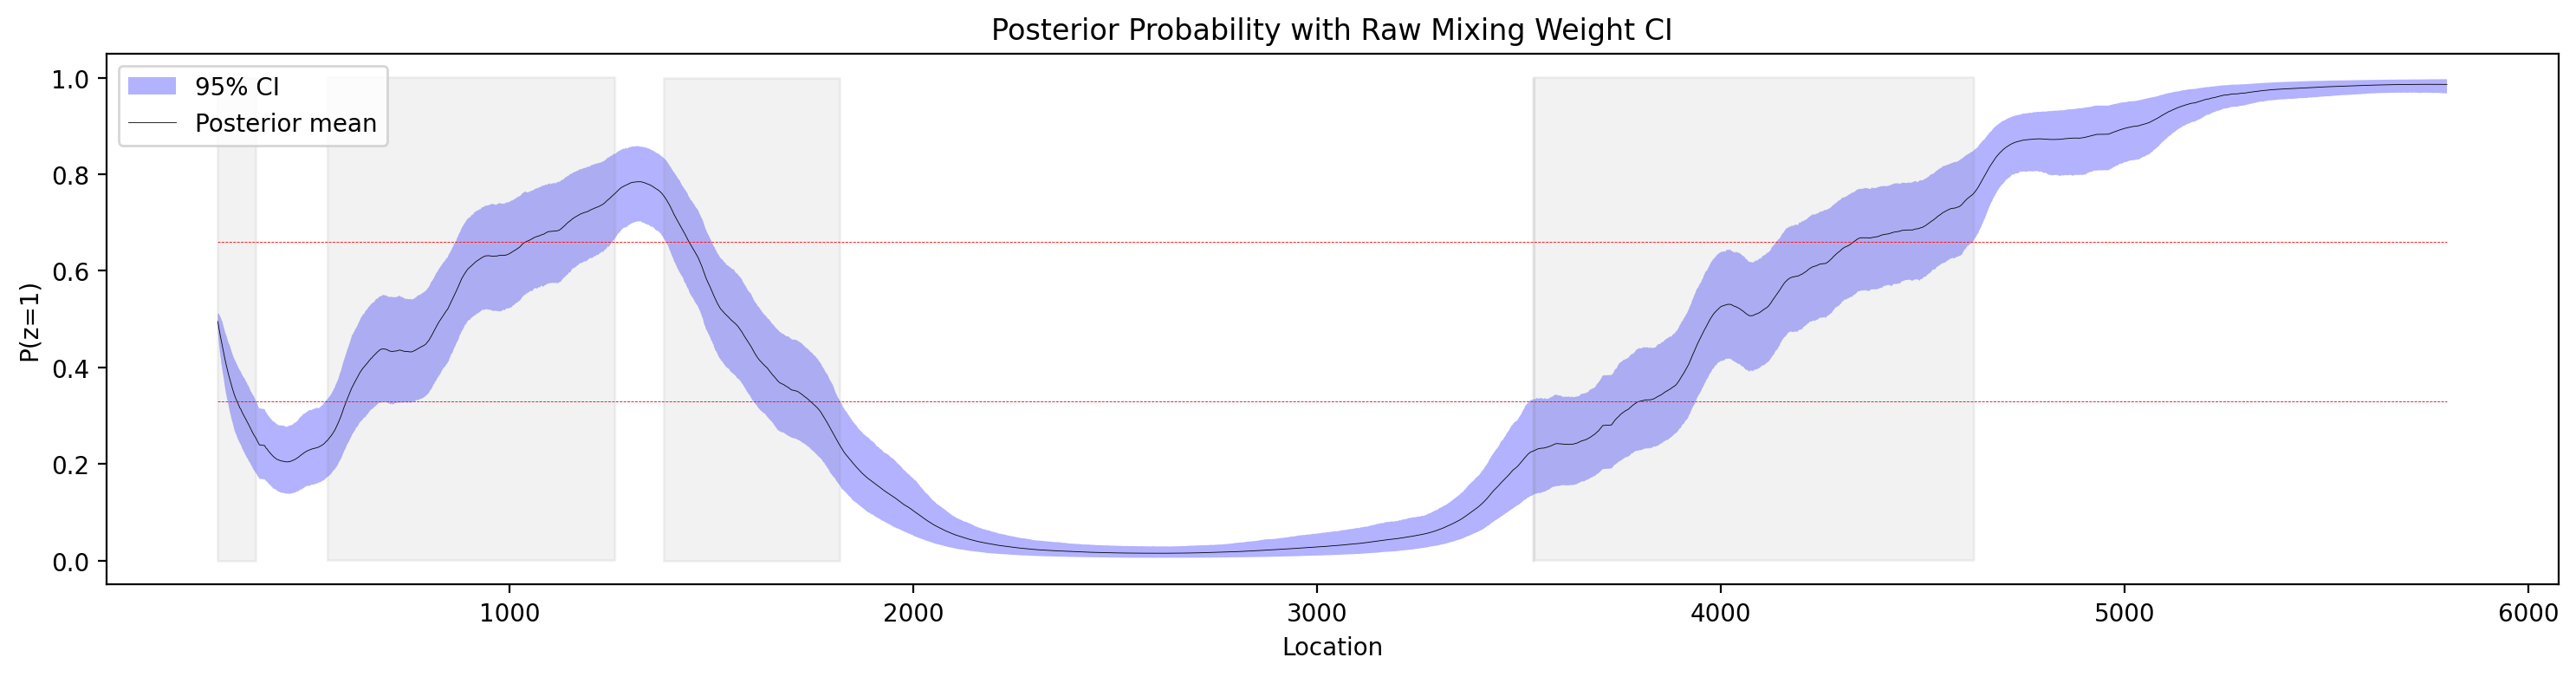

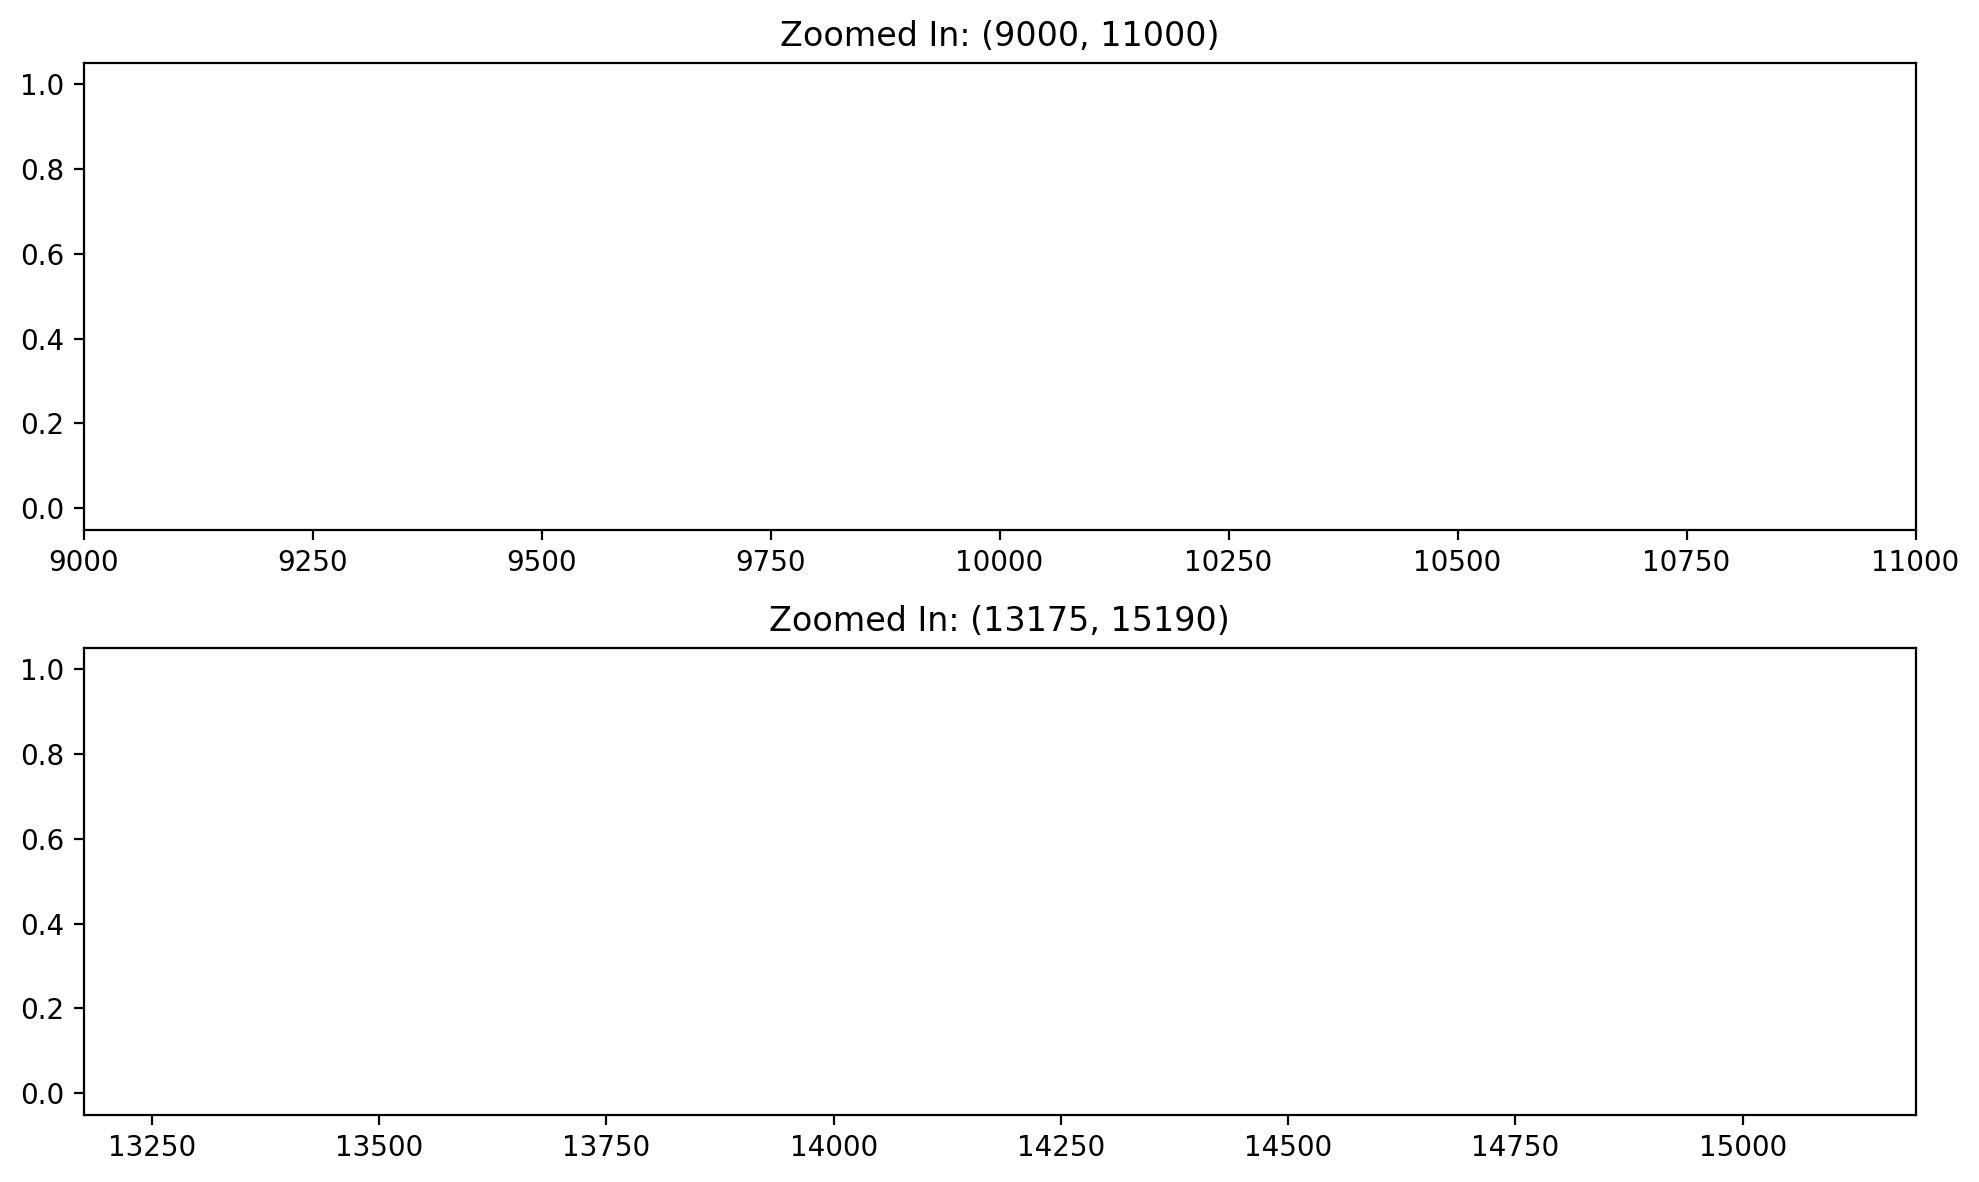

In [3]:
import matplotlib.pyplot as plt

# Set matplotlib to display SVG format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

x = w_stack["pos"]

f, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(
    x,
    w_ci_lower_direct,
    w_ci_upper_direct,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((w_ci_lower_direct < 1/3) & (w_ci_upper_direct < 1/3) | (w_ci_lower_direct > 2/3) & (w_ci_upper_direct > 2/3)),
    np.nan
)

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

# Plot the 0.5 line
ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)

plt.ylabel("P(z=1)")
plt.xlabel("Location")
plt.legend(loc='upper left')
plt.title("Posterior Probability with Raw Mixing Weight CI")
plt.tight_layout()
plt.show()

zooms = [(9000,11000), (13175, 15190)]

f, axs = plt.subplots(len(zooms), figsize=(10, 3*len(zooms)))

for i, zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        w_ci_lower_direct,
        w_ci_upper_direct,
        alpha=0.3,
        color="blue",
        ec='None'
    )

    # Grey band
    zax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
    color='gray')

    zax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)
    zax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
    zax.set_xlim(zoom)
    zax.set_title(f"Zoomed In: {zoom}")

plt.tight_layout()
plt.show()



So, how can we visualize the density of confidence band? 

I will try to plot all the curves with a very low alpha to see if it looks nice.

In [4]:
w_stack.isel(sample=slice(0,100))

<xarray.DataArray 'w' (pos: 5376, sample: 100)> Size: 4MB
array([[0.50725795, 0.50236237, 0.48869906, ..., 0.48200689, 0.51020253,
        0.47770391],
       [0.49259163, 0.50350673, 0.47523535, ..., 0.48239918, 0.4996335 ,
        0.475542  ],
       [0.49622794, 0.49605314, 0.47269892, ..., 0.48078163, 0.48958942,
        0.47887955],
       ...,
       [0.9922561 , 0.98917346, 0.99699292, ..., 0.98629383, 0.97987417,
        0.99127729],
       [0.99206913, 0.98948479, 0.99689928, ..., 0.98614678, 0.97972197,
        0.99134189],
       [0.99215481, 0.98911704, 0.99694458, ..., 0.98670249, 0.97855899,
        0.99200675]], shape=(5376, 100))
Coordinates:
  * pos      (pos) int64 43kB 278 279 280 281 282 ... 5794 5795 5796 5797 5798
  * sample   (sample) object 800B MultiIndex
  * chain    (sample) int64 800B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
  * draw     (sample) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99

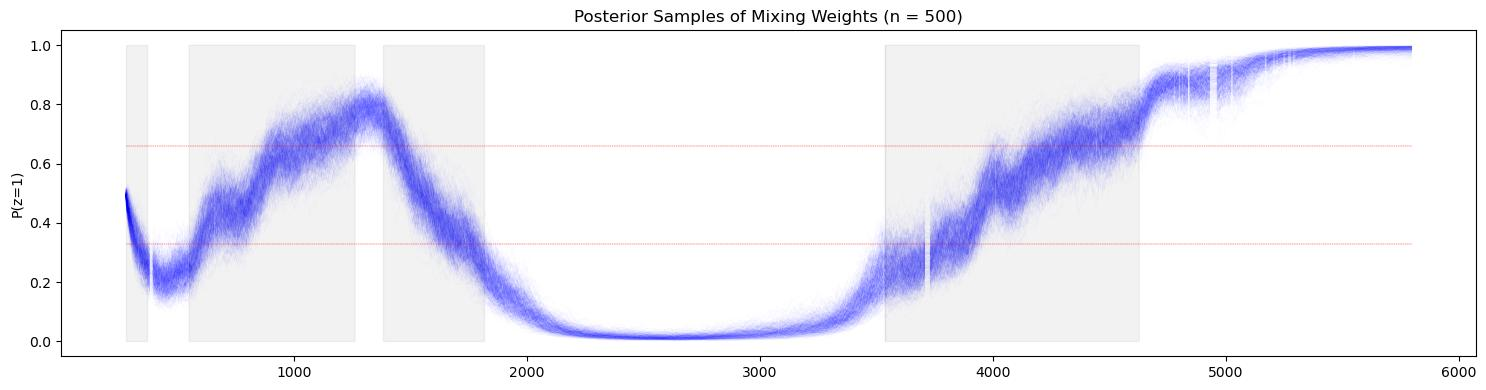

In [5]:
# Plot the all posterior samples of `w` in a single plot
# but start out with a smaller subset
# set the inline display to low dpi
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('jpg')

w_subset = w_stack.isel(sample=slice(0, 500))  # Adjust the slice as needed

f, ax = plt.subplots(figsize=(15, 4))

for i in range(w_subset.shape[1]):
    ax.plot(x, w_subset[:,i], alpha=0.1, linewidth=0.05, color="blue")

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
ax.set_ylabel("P(z=1)")

plt.title(f"Posterior Samples of Mixing Weights (n = {w_subset.shape[1]})")
plt.tight_layout()
plt.show()


## Translate into positional uncertainty

We translate the transitional regions (based on our CI rule) by counting the number of curves that cross the midpoint (0.5) between each position. Then we can summarize with statitics and establish the most likely transition. 

In [6]:
import numpy as np
import xarray as xr

w_np = w_stack.values  # Convert to numpy array
w_da = w_stack # Use the xarray DataArray directly


In [7]:
# Try again

# Boolean mask for values above threshold
above_thresh = w_da > 0.5

# Shift the boolean mask to find crossings
above_thresh_next = above_thresh.shift(pos=-1)

# Find crossings where the current value is above the threshold and the next value is below, or vice versa
crossings = above_thresh != above_thresh_next

# Convert the boolean crossings to integer values (1 for crossing, 0 for no crossing)
crossings = crossings.isel(pos=slice(20,-1)) # Remove the last position since it has no next value

# Sum the crossings across all samples to get the count of crossings at each position
crossing_counts = crossings.sum(dim="sample")

# Calculate the density of crossings
crossing_density = crossing_counts / w_da.shape[1]

# Normalize
crossing_density /= crossing_density.max()



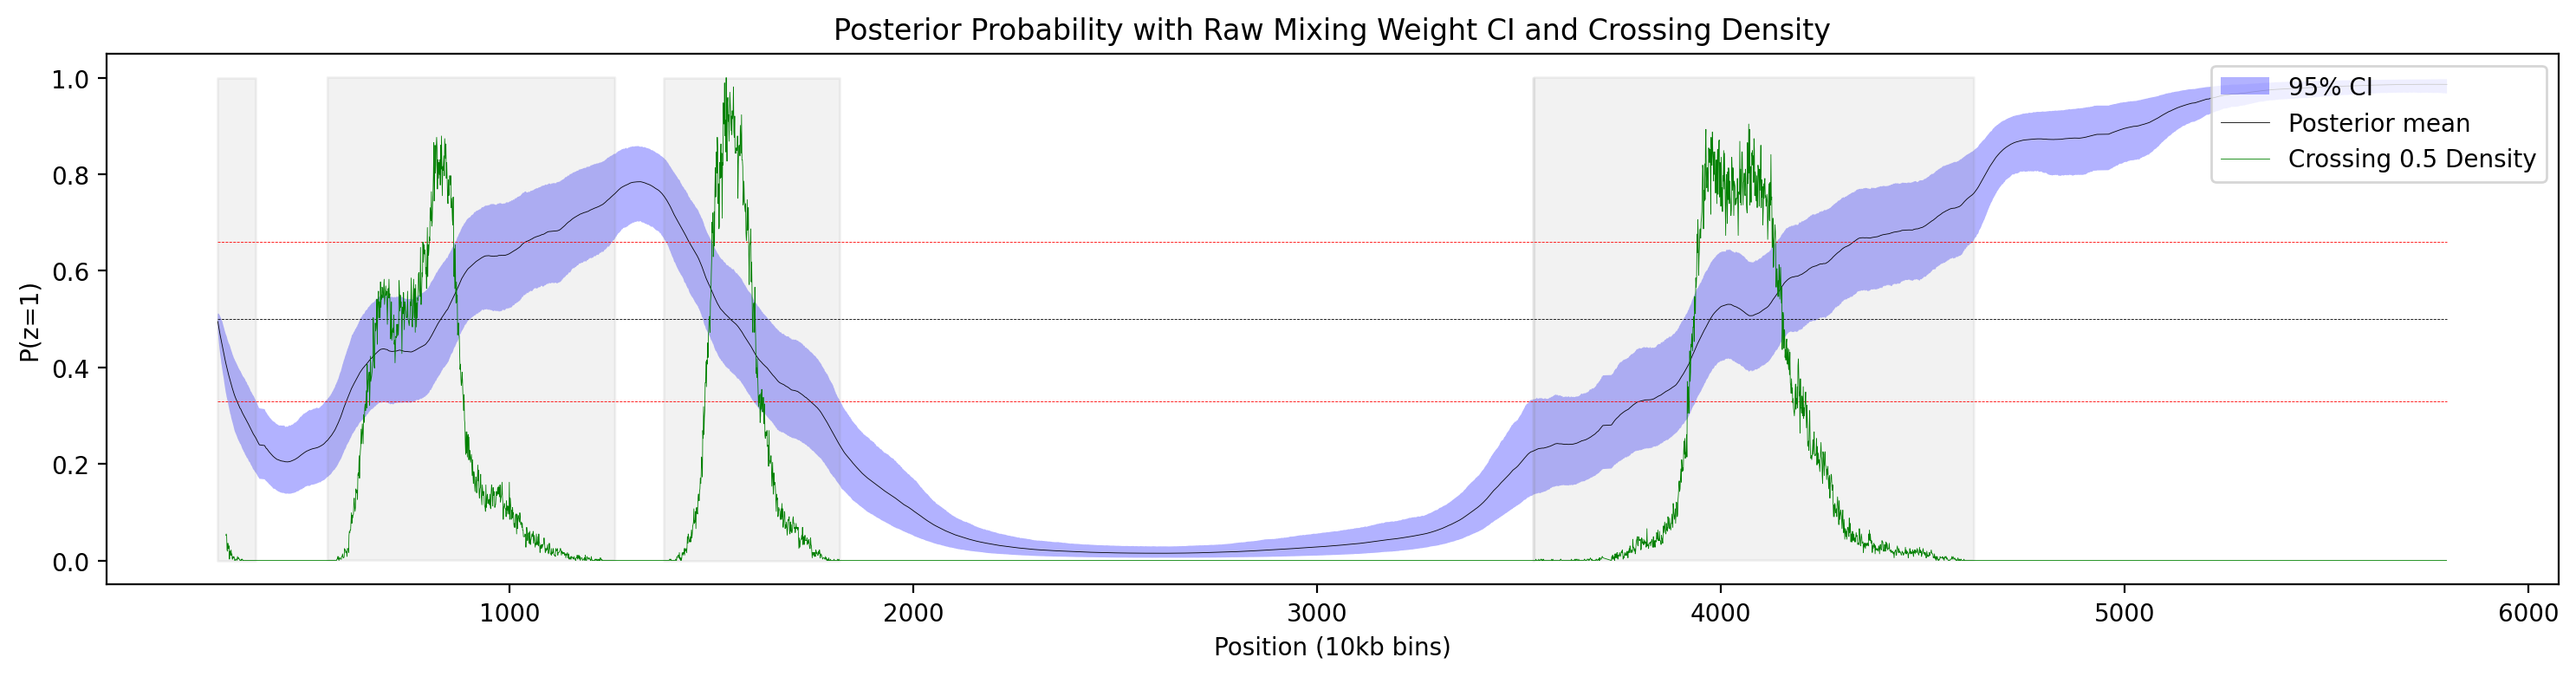

In [8]:
import matplotlib.pyplot as plt

# Set matplotlib to display SVG format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

x = w_stack["pos"]

f, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(
    x,
    w_ci_lower_direct,
    w_ci_upper_direct,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((w_ci_lower_direct < 1/3) & (w_ci_upper_direct < 1/3) | (w_ci_lower_direct > 2/3) & (w_ci_upper_direct > 2/3)),
    np.nan
)

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

# Plot the posterior mean
ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

# Plot the 0.5 line
ax.hlines([0.5], min(x), max(x), color="k", linestyle="--", linewidth=0.3)

# Plot the CI rules
ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)

# Plot the crossing counts
ax.plot(x[20:-1], crossing_density, label="Crossing 0.5 Density", color="green", linewidth=0.3)

plt.ylabel("P(z=1)")
plt.xlabel("Position (10kb bins)")
plt.legend(loc='upper right')
plt.title("Posterior Probability with Raw Mixing Weight CI and Crossing Density")
plt.tight_layout()
plt.show()

## Visualize the model

In [10]:
import pymc as pm

pm.__version__

'5.25.1'

In [11]:
# dummy model:
import pymc as pm
import cloudpickle as cp

model_path = "../results/models/07_hi_res_z_model.pkl"

with open(model_path, "rb") as f:
    model = cp.load(f)


print(pm.model_to_mermaid(model))

graph TD
%% Nodes:
eps([eps ~ Normal])
eps@{ shape: rounded }
grw_sigma([grw_sigma ~ Halfnormal])
grw_sigma@{ shape: rounded }
logit_w([logit_w ~ Deterministic])
logit_w@{ shape: rect }
mu([mu ~ Normal])
mu@{ shape: rounded }
sigma([sigma ~ Halfnormal])
sigma@{ shape: rounded }
w([w ~ Deterministic])
w@{ shape: rect }
y_hat([y_hat ~ Mixture])
y_hat@{ shape: rounded }
style y_hat fill:#757575
z([z ~ Bernoulli])
z@{ shape: rounded }

%% Edges:
eps --> logit_w
grw_sigma --> logit_w
logit_w --> w
mu --> y_hat
sigma --> y_hat
z --> y_hat
w --> z

%% Plates:
subgraph "label (2)"
    mu
    sigma
end
subgraph "pos (5376)"
    logit_w
    y_hat
    z
    w
    eps
end


In [12]:

from IPython.display import HTML, Markdown
import pymc as pm

# Displat in mermaid

print(pm.model_to_mermaid(model))

graph TD
%% Nodes:
eps([eps ~ Normal])
eps@{ shape: rounded }
grw_sigma([grw_sigma ~ Halfnormal])
grw_sigma@{ shape: rounded }
logit_w([logit_w ~ Deterministic])
logit_w@{ shape: rect }
mu([mu ~ Normal])
mu@{ shape: rounded }
sigma([sigma ~ Halfnormal])
sigma@{ shape: rounded }
w([w ~ Deterministic])
w@{ shape: rect }
y_hat([y_hat ~ Mixture])
y_hat@{ shape: rounded }
style y_hat fill:#757575
z([z ~ Bernoulli])
z@{ shape: rounded }

%% Edges:
eps --> logit_w
grw_sigma --> logit_w
logit_w --> w
mu --> y_hat
sigma --> y_hat
z --> y_hat
w --> z

%% Plates:
subgraph "label (2)"
    mu
    sigma
end
subgraph "pos (5376)"
    logit_w
    y_hat
    z
    w
    eps
end


In [ ]:


import mermaid as md
mermaid_code = pm.model_to_mermaid(model)

render = md.Mermaid(mermaid_code)
render